In [4]:
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
from keras.applications import VGG19
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [5]:
# Load VGG-16 model without top (fully connected layers)
vgg_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [6]:
# Define function to extract features using VGG-16
def extract_features(generator, model):
    features = model.predict(generator, verbose=1)
    return features

In [7]:
# Directory paths for train and test data
train_dir = "Processed_Dataset_2/train"
test_dir = "Processed_Dataset_2/test"

# Define image size and batch size
image_size = (224, 224)
batch_size = 32

In [8]:
# Create data generators for train and test data
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode=None,  # No labels are returned
    shuffle=False  # Important: Keep the order of the images
)

Found 4672 images belonging to 2 classes.


In [9]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode=None,
    shuffle=False
)

Found 1168 images belonging to 2 classes.


In [10]:
# Extract features for train and test data
train_features = extract_features(train_generator, vgg_model)
test_features = extract_features(test_generator, vgg_model)

37/37 [==============================] - 580s 16s/step


In [11]:
# Flatten features
train_features_flatten = np.reshape(train_features, (train_features.shape[0], -1))
test_features_flatten = np.reshape(test_features, (test_features.shape[0], -1))

In [12]:
# Train Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(train_features_flatten, train_generator.classes)

RandomForestClassifier(random_state=42)

In [13]:
# Predict using Random Forest classifier
predictions = rf_classifier.predict(test_features_flatten)

In [14]:
# Calculate accuracy
accuracy = accuracy_score(test_generator.classes, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.8707191780821918


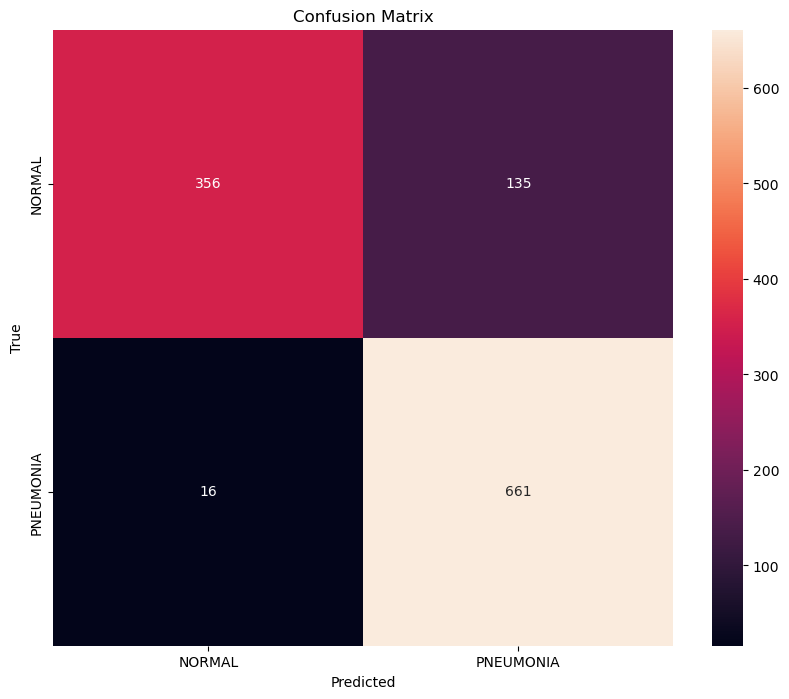

In [17]:
# Calculate confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_generator.classes, predictions)

# Plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
